# Decision Trees

## What is a Decision Tree?
A Decision Tree is a **non-parametric** supervised learning algorithm that partitions the feature space into axis-aligned rectangles and assigns a label or value to each partition.

**History**: ID3 (1986) by Ross Quinlan → C4.5 (1993) → C5.0. CART (1984) by Breiman et al.

---

## 1. Key Concepts

- **Node**: A question about a feature value
- **Branch**: The outcome of a question
- **Leaf**: Terminal node the prediction
- **Root**: The top-most node (best feature to split on)

---

## 2. Splitting Criteria

### Entropy (Information Gain)

$$H(S) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

Information Gain:
$$IG(S, A) = H(S) - \sum_{v \in \text{Values}(A)} \frac{|S_v|}{|S|} H(S_v)$$

Choose feature $A$ that **maximizes** $IG$.

### Gini Impurity

$$G(S) = 1 - \sum_{k=1}^{K} p_k^2$$

Gini is $0$ for pure nodes, max $\frac{K-1}{K}$ for uniform distribution.

Weighted Gini for split:
$$G_{split} = \frac{n_{left}}{n}G_{left} + \frac{n_{right}}{n}G_{right}$$

### Mean Squared Error (Regression Trees)

$$MSE_{node} = \frac{1}{n}\sum_{i \in node}(y_i - \bar{y}_{node})^2$$

---

## 3. Algorithm Comparison

| Algorithm | Split Criterion | Handles Missing? | Pruning | Multi-output? |
|-----------|----------------|-----------------|---------|---------------|
| **ID3** | Information Gain | No | No | No |
| **C4.5** | Gain Ratio | Yes | Yes (post) | No |
| **CART** | Gini / MSE | Yes (surrogates) | Yes (cost-complexity) | Yes |

---

## 4. Pruning

**Pre-pruning (early stopping)**: `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`

**Post-pruning (CART)**: Cost-complexity pruning. Define:
$$R_\alpha(T) = R(T) + \alpha|\tilde{T}|$$

Where $R(T)$ is the misclassification rate and $|\tilde{T}|$ is the number of leaves. Increase $\alpha$ to get simpler trees.

---

## 5. Feature Importance

$$\text{FI}(j) = \frac{\sum_{t: \text{split on } j} n_t \cdot \Delta\text{impurity}_t}{\sum_t n_t \cdot \Delta\text{impurity}_t}$$

Higher importance = feature was used in splits that reduced impurity more.

---

## 6. Advantages & Disadvantages

**Pros**: Interpretable, no scaling needed, handles mixed types, fast

**Cons**: High variance (overfitting), unstable (sensitive to data), axis-aligned splits only

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Decision Tree from Scratch

In [2]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # for leaf nodes

class DecisionTreeScratch:
    def __init__(self, max_depth=10, min_samples_split=2, criterion='gini'):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.root = None

    def _gini(self, y):
        classes, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)

    def _entropy(self, y):
        classes, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return -np.sum(probs * np.log2(probs + 1e-15))

    def _impurity(self, y):
        return self._gini(y) if self.criterion == 'gini' else self._entropy(y)

    def _best_split(self, X, y):
        best_feat, best_thresh, best_gain = None, None, -np.inf
        parent_imp = self._impurity(y)
        m, n = X.shape
        for feat in range(n):
            thresholds = np.unique(X[:, feat])
            for t in thresholds:
                left_mask = X[:, feat] <= t
                left_y, right_y = y[left_mask], y[~left_mask]
                if len(left_y) == 0 or len(right_y) == 0: continue
                gain = parent_imp - (len(left_y)/m * self._impurity(left_y) +
                                     len(right_y)/m * self._impurity(right_y))
                if gain > best_gain:
                    best_gain, best_feat, best_thresh = gain, feat, t
        return best_feat, best_thresh

    def _build(self, X, y, depth):
        if depth >= self.max_depth or len(y) < self.min_samples_split or len(np.unique(y)) == 1:
            values, counts = np.unique(y, return_counts=True)
            return Node(value=values[np.argmax(counts)])
        feat, thresh = self._best_split(X, y)
        if feat is None:
            values, counts = np.unique(y, return_counts=True)
            return Node(value=values[np.argmax(counts)])
        mask = X[:, feat] <= thresh
        left = self._build(X[mask], y[mask], depth + 1)
        right = self._build(X[~mask], y[~mask], depth + 1)
        return Node(feature=feat, threshold=thresh, left=left, right=right)

    def fit(self, X, y):
        self.root = self._build(X, y, 0)

    def _traverse(self, x, node):
        if node.value is not None: return node.value
        if x[node.feature] <= node.threshold: return self._traverse(x, node.left)
        return self._traverse(x, node.right)

    def predict(self, X): return np.array([self._traverse(x, self.root) for x in X])


scratch_tree = DecisionTreeScratch(max_depth=5)
scratch_tree.fit(X_train, y_train)
print(f'Scratch Tree Accuracy: {accuracy_score(y_test, scratch_tree.predict(X_test)):.4f}')

Scratch Tree Accuracy: 1.0000


## Scikit-Learn Decision Trees & Visualization

Sklearn Accuracy: 1.0000


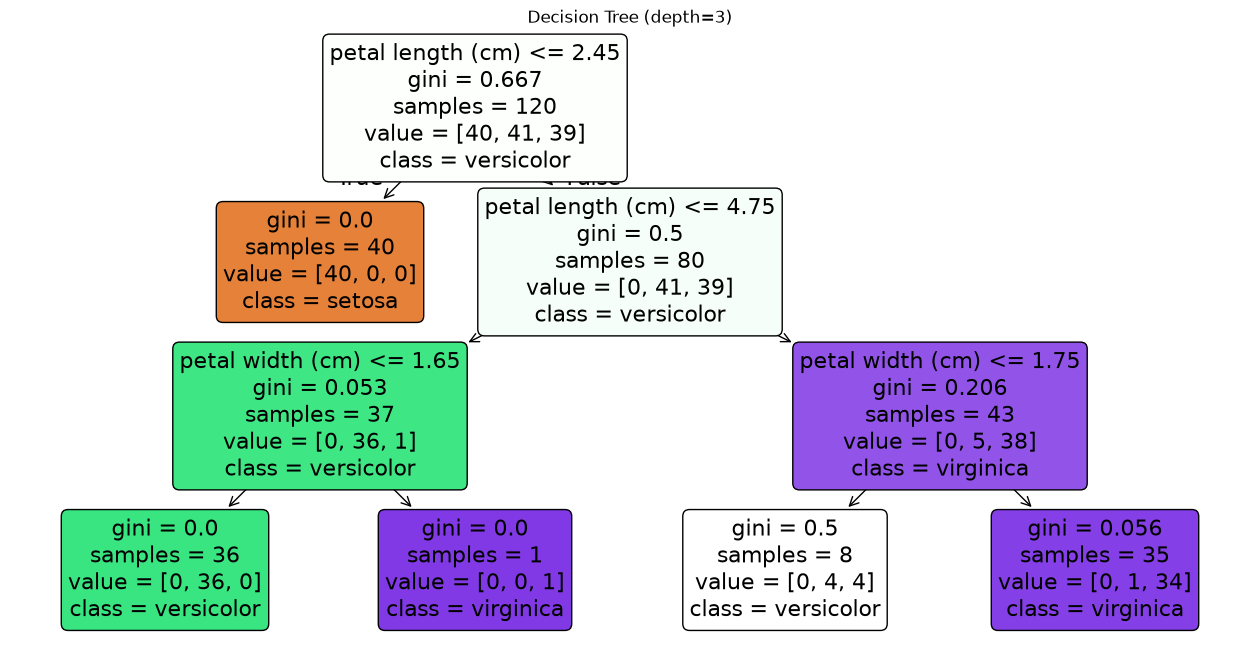

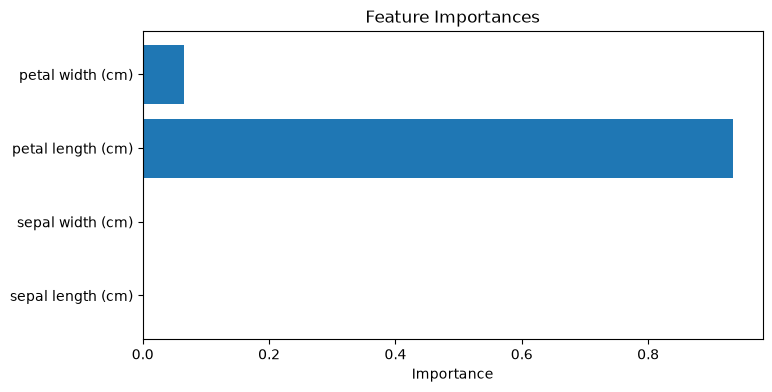

In [3]:
iris = load_iris()
clf = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
clf.fit(X_train, y_train)

print(f'Sklearn Accuracy: {clf.score(X_test, y_test):.4f}')

# Visualize the tree
plt.figure(figsize=(16, 8))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True)
plt.title('Decision Tree (depth=3)')
plt.show()

# Feature importance
importance = clf.feature_importances_
plt.figure(figsize=(8, 4))
plt.barh(iris.feature_names, importance)
plt.xlabel('Importance'); plt.title('Feature Importances'); plt.show()

## Pruning Effect of max_depth

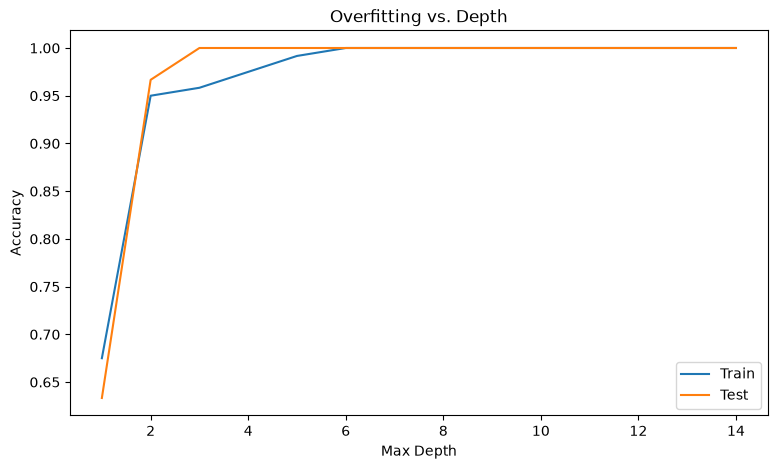

In [4]:
depths = range(1, 15)
train_scores, test_scores = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, label='Train')
plt.plot(depths, test_scores, label='Test')
plt.xlabel('Max Depth'); plt.ylabel('Accuracy')
plt.title('Overfitting vs. Depth'); plt.legend(); plt.show()

## Cost-Complexity Pruning

Cost-complexity pruning (also called weakest-link pruning) is the post-pruning strategy used by CART. It introduces a complexity parameter `ccp_alpha`. For each value of alpha, branches that contribute less than alpha to the overall accuracy are pruned. As alpha increases the tree is pruned more aggressively, trading training accuracy for better generalisation. The optimal alpha is selected by cross-validation.

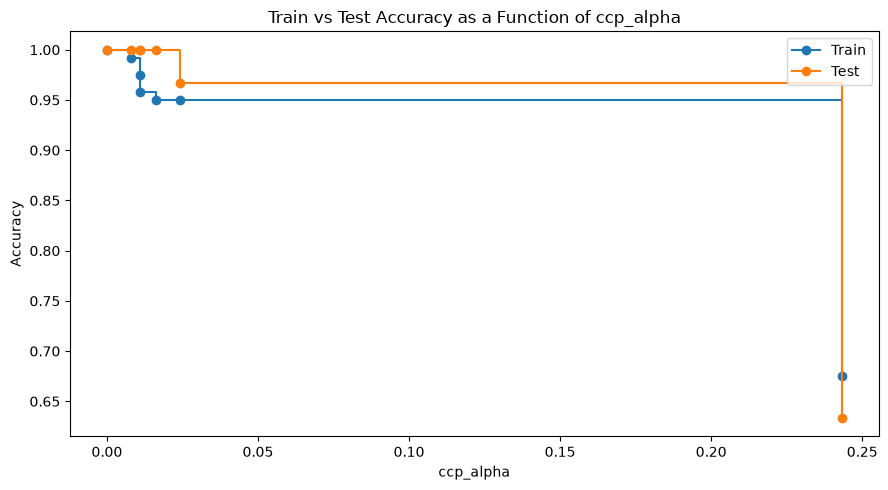

In [5]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # remove the trivial last entry

clfs = []
for alpha in ccp_alphas:
    c = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    c.fit(X_train, y_train)
    clfs.append(c)

train_scores = [c.score(X_train, y_train) for c in clfs]
test_scores  = [c.score(X_test,  y_test)  for c in clfs]

plt.figure(figsize=(9, 5))
plt.plot(ccp_alphas, train_scores, marker='o', label='Train', drawstyle='steps-post')
plt.plot(ccp_alphas, test_scores,  marker='o', label='Test',  drawstyle='steps-post')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy as a Function of ccp_alpha')
plt.legend()
plt.tight_layout()
plt.show()

## Turning a Tree into Human-Readable Business Rules

`export_text` prints the decision tree as an indented text representation. Each line shows the feature threshold used at that node and the class distribution at the leaves. This is how a trained tree can be translated directly into if-else business rules that domain experts can read, audit, and implement without any machine learning tooling.

In [6]:
from sklearn.tree import export_text

iris = load_iris()
feature_names = iris.feature_names

clf_small = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_small.fit(X_train, y_train)
rules = export_text(clf_small, feature_names=list(feature_names))
print(rules)

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2



## Learning Curve

A learning curve plots training and validation accuracy as a function of training-set size. A large gap between the training curve and the validation curve signals overfitting: the model memorises the training data but fails to generalise. When both curves converge at a low accuracy, the model is underfitting and more data will not help. The ideal outcome is both curves converging at a high accuracy.

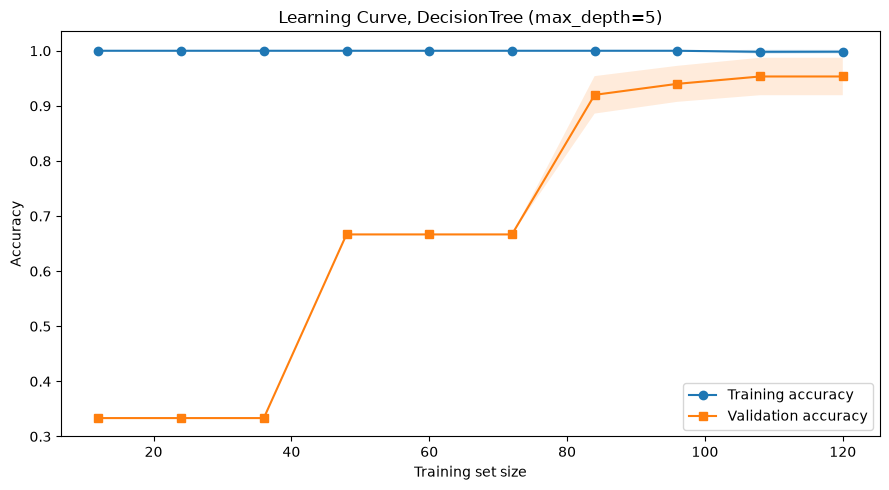

In [7]:
from sklearn.model_selection import learning_curve, StratifiedKFold

train_sizes, lc_train_scores, lc_val_scores = learning_curve(
    DecisionTreeClassifier(max_depth=5, random_state=42),
    X, y,
    cv=StratifiedKFold(5),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

lc_train_mean = lc_train_scores.mean(axis=1)
lc_train_std  = lc_train_scores.std(axis=1)
lc_val_mean   = lc_val_scores.mean(axis=1)
lc_val_std    = lc_val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, lc_train_mean, 'o-', label='Training accuracy')
plt.fill_between(train_sizes, lc_train_mean - lc_train_std,
                              lc_train_mean + lc_train_std, alpha=0.15)
plt.plot(train_sizes, lc_val_mean, 's-', label='Validation accuracy')
plt.fill_between(train_sizes, lc_val_mean - lc_val_std,
                              lc_val_mean + lc_val_std, alpha=0.15)
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning Curve, DecisionTree (max_depth=5)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Regression Tree

In [8]:
from sklearn.metrics import mean_squared_error

X_reg, y_reg = load_diabetes(return_X_y=True)
X_rtr, X_rte, y_rtr, y_rte = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_tree = DecisionTreeRegressor(max_depth=5, random_state=42)
reg_tree.fit(X_rtr, y_rtr)
preds = reg_tree.predict(X_rte)
print(f'Regression Tree RMSE: {np.sqrt(mean_squared_error(y_rte, preds)):.2f}')

Regression Tree RMSE: 59.38


## Additional Learning Resources

### Papers
- 📄 [CART: Classification and Regression Trees (1984)](https://www.taylorfrancis.com/books/mono/10.1201/9781315139470/classification-regression-trees-leo-breiman) Breiman et al.
- 📄 [C4.5: Programs for Machine Learning](https://link.springer.com/article/10.1023/A:1022643204877) Quinlan (1993)
- 📄 [ID3 Algorithm](https://link.springer.com/article/10.1007/BF00116251) Quinlan (1986)

### Books
- 📖 [ISLR Chapter 8](https://www.statlearning.com/) Tree-Based Methods
- 📖 [ESL Chapter 9](https://web.stanford.edu/~hastie/ElemStatLearn/) Additive Models, Trees

### Videos
- 🎥 [StatQuest: Decision Trees](https://www.youtube.com/watch?v=_L39rN6gz7Y)
- 🎥 [StatQuest: Decision Tree Regression](https://www.youtube.com/watch?v=g9c66TUylZ4)

### Documentation
- 📚 [Scikit-Learn Decision Trees](https://scikit-learn.org/stable/modules/tree.html)